# Introducción

Este notebook de Análisis Exploratorio de Datos (EDA) Manual ha sido diseñado como una herramienta versátil y configurable para el usuario. Su objetivo es facilitar el proceso de exploración y análisis de datos mediante funciones predeterminadas y código estandarizado, permitiendo a los usuarios centrarse en la interpretación de los resultados.

## Características Predeterminadas

Este notebook incluye funciones para realizar:

1. **Análisis Bivariado**:
   - Relaciones entre variables categóricas utilizando gráficos de barras apiladas.
   - Relaciones entre variables categóricas y numéricas mediante gráficos combinados como `histplot`.

2. **Análisis de Correlación**:
   - Cálculo de correlación utilizando la prueba de chi-cuadrado.

3. **Análisis de Reducción de Dimensionalidad**:
   - PCA (Análisis de Componentes Principales) para datos numéricos.
   - FAMD (Factorial Analysis of Mixed Data) para datos mixtos (numéricos y categóricos).

4. **Tests de Hipótesis**:
   - **Pruebas de normalidad**: Evaluar si los datos siguen una distribución normal.
   - **Pruebas de correlación**: Spearman, Pearson, Kendall, etc.
   - **Chi-cuadrado**: Para evaluar la independencia entre variables categóricas.
   - **Tests paramétricos**: T-test, ANOVA, entre otros.
   - **Tests no paramétricos**: Mann-Whitney U, Kruskal-Wallis, Wilcoxon, entre otros.

## Configuración y Uso

El usuario puede personalizar este notebook proporcionando datos necesarios como:
- La ubicación del archivo CSV o dataset.
- Los nombres de las columnas de interés.
- Parámetros específicos para las funciones de análisis.

Con estas configuraciones mínimas, el notebook realizará el análisis automáticamente, presentando resultados gráficos y estadísticos para facilitar la interpretación.

**Nota**: Este notebook está diseñado para ser utilizado de manera interactiva, ayudando a los usuarios a comprender los datos y generar hipótesis para futuros análisis.



In [1]:
# Carga y Previsualización del Dataset


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ruta del archivo CSV (puede ser configurada por el usuario)
file_path = r"C:\Users\espin\Desktop\Experimentos\Test 38\processed\processed_eda_titanic.csv"
  # Reemplaza con la ruta de tu archivo

# Cargar el dataset
df = pd.read_csv(file_path)

# Previsualización general del dataset
print("\nPrevisualización del Dataset:\n")
display(df.head())

# Información general sobre el dataset
print("\nInformación del Dataset:\n")
display(df.info())




Previsualización del Dataset:



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,vacio,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,vacio,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,vacio,Southampton,no,True



Información del Dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     714 non-null    int64  
 1   pclass       714 non-null    int64  
 2   sex          714 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        714 non-null    int64  
 5   parch        714 non-null    int64  
 6   fare         714 non-null    float64
 7   embarked     714 non-null    object 
 8   class        714 non-null    object 
 9   who          714 non-null    object 
 10  adult_male   714 non-null    bool   
 11  deck         714 non-null    object 
 12  embark_town  714 non-null    object 
 13  alive        714 non-null    object 
 14  alone        714 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 74.0+ KB


None

In [6]:
# Clasificación de las variables en función de sus características
categorical = []
numerical = []
binary = []

for column in df.columns:
    unique_values = df[column].nunique()
    if unique_values == 2:  # Variables categoricas binarias
        binary.append(column)
    elif df[column].dtype == 'object':  # Variables categóricas no binarias
        categorical.append(column)
    elif df[column].dtype in ['int64', 'float64']:  # Variables numéricas
        numerical.append(column)

# Mostrar clasificación de variables
print("\nClasificación de las variables:\n")
print(f"Variables categoricas binarias: {binary}")
print(f"Variables categóricas: {categorical}")
print(f"Variables numéricas: {numerical}")



Clasificación de las variables:

Variables categoricas binarias: ['survived', 'sex', 'adult_male', 'alive', 'alone']
Variables categóricas: ['embarked', 'class', 'who', 'deck', 'embark_town']
Variables numéricas: ['pclass', 'age', 'sibsp', 'parch', 'fare']


# 1. Gráficos de Barras Apiladas (Variables Categóricas)
## Ejemplo: Relación entre class_Third y sex_male

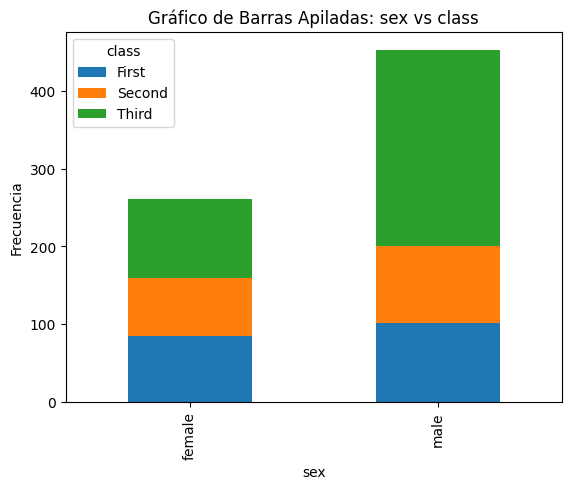

In [7]:
# Configura las columnas categóricas
categ_var1 = 'sex'
categ_var2 = 'class'

# Gráfico de barras apiladas
pd.crosstab(df[categ_var1], df[categ_var2]).plot(kind='bar', stacked=True)
plt.title(f'Gráfico de Barras Apiladas: {categ_var1} vs {categ_var2}')
plt.xlabel(categ_var1)
plt.ylabel('Frecuencia')
plt.show()

# 2. Boxplots (Variables Categóricas vs Numéricas)
## Ejemplo: Relación entre age y sex_male

c:\Users\espin\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


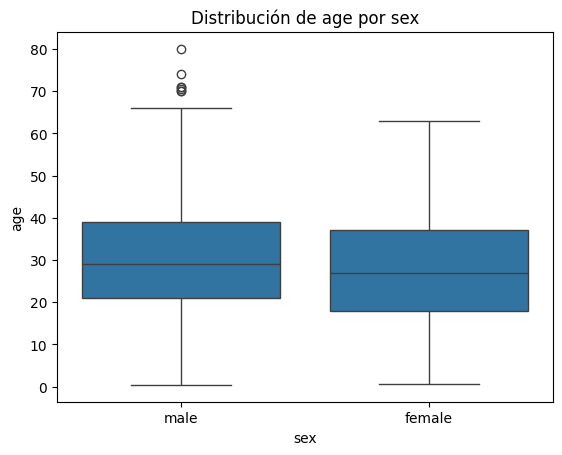

In [13]:
# Configura las columnas categórica y numérica
categ_var = 'sex'
num_var = 'age'

# Boxplot para comparar la distribución de PetalLengthCm por Species_Iris-setosa
sns.boxplot(x=categ_var, y=num_var, data=df)
plt.title(f'Distribución de {num_var} por {categ_var}')
plt.xlabel(categ_var)
plt.ylabel(num_var)
plt.show()

# 3. Histplot (Distribución de variables numéricas por categorías)
## Ejemplo: Relación entre fare y alive_yes

c:\Users\espin\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\espin\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\espin\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

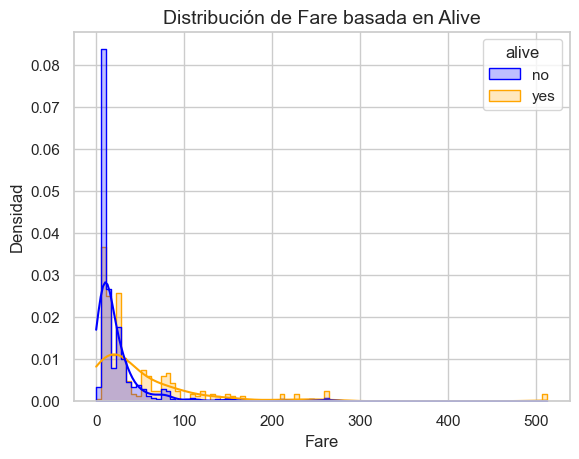

In [14]:
# Histplot (Distribución de Variables Numéricas por Categorías)

## Ejemplo: Distribución de Edad basada en Supervivencia

num_var = 'fare'      # Variable numérica
hue_var = 'alive'    # Variable categórica para la leyenda

# Estilo del gráfico
sns.set(style="whitegrid", context='notebook')

# Crear gráfico para la variable numérica
sns.histplot(
    data=df, x=num_var, hue=hue_var, kde=True, element="step",
    stat="density", common_norm=False, palette=["blue", "orange"]
)
plt.title(f'Distribución de {num_var.capitalize()} basada en {hue_var.capitalize()}', fontsize=14)
plt.xlabel(num_var.capitalize(), fontsize=12)
plt.ylabel("Densidad", fontsize=12)
plt.show()

# 4. **Análisis de Reducción de Dimensionalidad**:
   - PCA (Análisis de Componentes Principales) para datos numéricos.
   - FAMD (Factorial Analysis of Mixed Data) para datos mixtos (numéricos y categóricos).
   # Análisis de Reducción de Dimensionalidad (FAMD)

## ¿Qué es FAMD?

El Análisis Factorial de Mezcla de Datos (FAMD, por sus siglas en inglés) es una técnica que combina variables numéricas y categóricas en un análisis de componentes principales. Es ideal para conjuntos de datos mixtos, ya que permite representar las relaciones entre todas las variables en un espacio de baja dimensión.

### Objetivo

El objetivo de esta sección es reducir la dimensionalidad del dataset para comprender las relaciones entre las variables, utilizando gráficos bidimensionales o tridimensionales.


### Interpretación
1. **Gráfico 2D**: Muestra la proyección de las variables en los dos primeros componentes principales.
2. **Gráfico 3D**: Permite explorar la relación en tres dimensiones.

Esta plantilla es completamente ajustable para que el usuario utilice su propio dataset, definan variables relevantes y analicen las relaciones presentes.

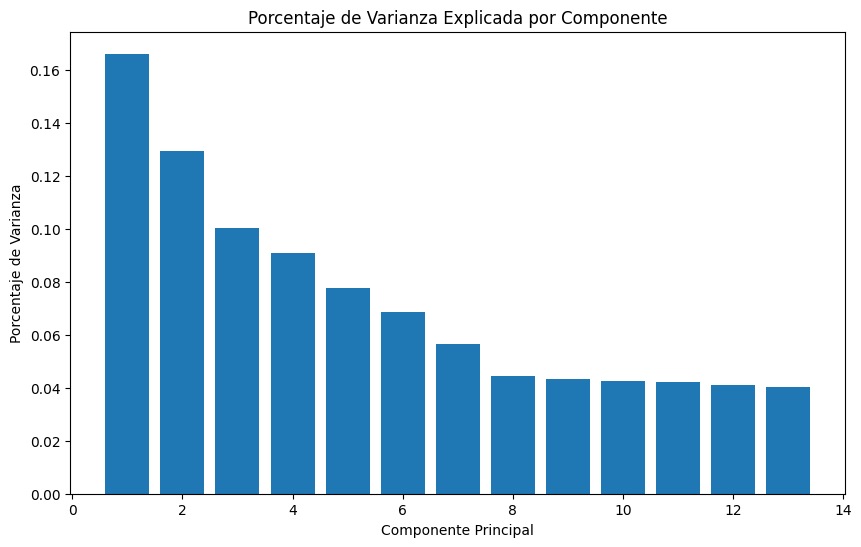

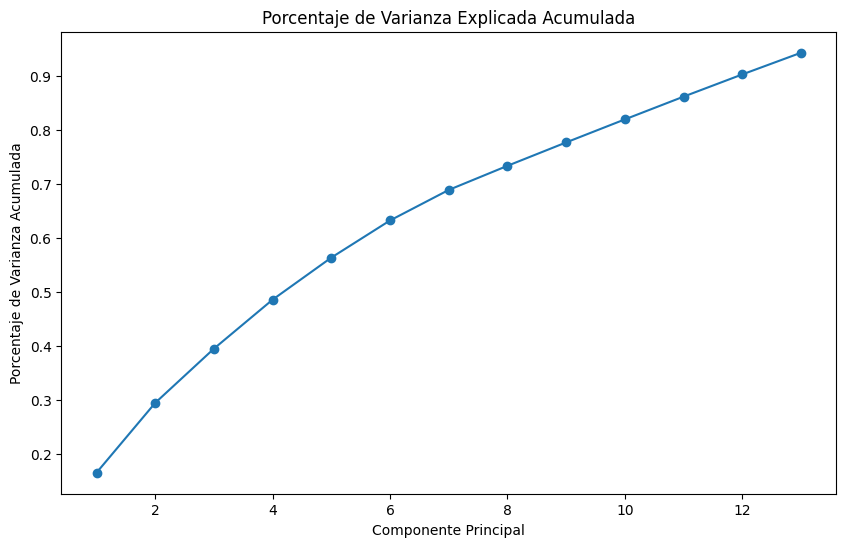

: 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import prince
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# ====================================
# 1. Carga del Dataset
# ====================================
# Cargar el dataset previamente cargado en la celda inicial del notebook.
# df es el DataFrame base para el análisis.

# ====================================
# 2. Configuración de Variables
# ====================================
# Propósito: Identificar las variables categóricas y numéricas que se usarán en el análisis.
# Ajusta estas listas según las características de tu dataset.

categorical_vars = ['sex', 'alone', 'class', 'embark_town', 'who', 'adult_male', 'deck']
numerical_vars = ['age', 'sibsp', 'parch', 'fare']
output_vars = ['survived', 'alive']  # Variables de salida a excluir del análisis

# Convertir las variables categóricas a string para compatibilidad con prince
for var in categorical_vars:
    df[var] = df[var].astype('str')

# ====================================
# 3. Preparación de los Datos
# ====================================
# Propósito: Remover las variables de salida y estandarizar las variables numéricas.

df_no_output = df.drop(columns=output_vars)

# Estandarizar las variables numéricas
scaler = StandardScaler()
df_no_output[numerical_vars] = scaler.fit_transform(df_no_output[numerical_vars])

# ====================================
# 4. Análisis FAMD
# ====================================
# Propósito: Reducir la dimensionalidad del dataset y analizar las relaciones entre variables numéricas y categóricas.

# Determinar el número de componentes basado en el número de columnas restantes
n_components = df_no_output.shape[1]

famd = prince.FAMD(
    n_components=n_components,  # Ajuste dinámico
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)
famd = famd.fit(df_no_output)

# Transformar los datos con FAMD
famd_result = famd.transform(df_no_output)

# ====================================
# 5. Visualización de Varianza Explicada
# ====================================
# Propósito: Mostrar cuánta varianza explica cada componente principal y evaluar si los componentes seleccionados son suficientes.

summary_famd = famd.eigenvalues_summary
summary_famd['% of variance'] = summary_famd['% of variance'].str.rstrip('%').astype('float') / 100.0
summary_famd['% of variance (cumulative)'] = summary_famd['% of variance (cumulative)'].str.rstrip('%').astype('float') / 100.0

# Gráfico de barras para la varianza explicada
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    x=np.arange(len(summary_famd)) + 1,
    height=summary_famd['% of variance']
)
ax.set_title('Porcentaje de Varianza Explicada por Componente')
ax.set_xlabel('Componente Principal')
ax.set_ylabel('Porcentaje de Varianza')
plt.show()

# Gráfico de varianza acumulada
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    np.arange(len(summary_famd)) + 1,
    summary_famd['% of variance (cumulative)'],
    marker='o'
)
ax.set_title('Porcentaje de Varianza Explicada Acumulada')
ax.set_xlabel('Componente Principal')
ax.set_ylabel('Porcentaje de Varianza Acumulada')
plt.show()

# ====================================
# 6. Visualización 2D y 3D de las Proyecciones
# ====================================
# Propósito: Visualizar cómo los datos originales se proyectan en los componentes principales.

# Gráfico 2D con Plotly
fig2d = go.Figure(data=go.Scatter(
    x=famd_result[0], y=famd_result[1], mode='markers'
))
fig2d.update_layout(
    title='FAMD - 2D',
    xaxis_title='Componente 1',
    yaxis_title='Componente 2'
)
fig2d.show()

# Gráfico 3D con Plotly
fig3d = go.Figure(data=go.Scatter3d(
    x=famd_result[0], y=famd_result[1], z=famd_result[2], mode='markers'
))
fig3d.update_layout(
    scene=dict(
        xaxis_title='Componente 1',
        yaxis_title='Componente 2',
        zaxis_title='Componente 3'
    ),
    title='FAMD - 3D'
)
fig3d.show()

# ====================================
# 7. Visualización de Contribuciones por Componente
# ====================================
# Propósito: Analizar qué variables contribuyen más a cada componente.

coordenadas_componentes = famd.column_coordinates_
coordenadas_componentes_transposed = coordenadas_componentes.T

# Gráfico 2D con Plotly
trace = go.Scatter(
    x=coordenadas_componentes_transposed.loc[0],
    y=coordenadas_componentes_transposed.loc[1],
    mode='markers+text',
    text=coordenadas_componentes_transposed.columns,
    textposition='top center'
)
layout = go.Layout(
    title='Gráfico 2D - Contribuciones de Variables',
    xaxis=dict(title='Componente 1'),
    yaxis=dict(title='Componente 2')
)
fig2d_contrib = go.Figure(data=[trace], layout=layout)
fig2d_contrib.show()

# Gráfico 3D con Plotly
trace3d = go.Scatter3d(
    x=coordenadas_componentes_transposed.loc[0],
    y=coordenadas_componentes_transposed.loc[1],
    z=coordenadas_componentes_transposed.loc[2],
    mode='markers+text',
    text=coordenadas_componentes_transposed.columns,
    textposition='top center'
)
layout3d = go.Layout(
    title='Gráfico 3D - Contribuciones de Variables',
    scene=dict(
        xaxis=dict(title='Componente 1'),
        yaxis=dict(title='Componente 2'),
        zaxis=dict(title='Componente 3')
    )
)
fig3d_contrib = go.Figure(data=[trace3d], layout=layout3d)
fig3d_contrib.show()

# ====================================
# Nota Final para el Usuario
# ====================================
# - Cambia las listas de variables categóricas y numéricas según tu dataset.
# - Este código está diseñado para ser flexible y adaptable a diferentes datasets.
# - Asegúrate de instalar las bibliotecas necesarias antes de ejecutar el código: `pip install prince matplotlib plotly`.






